In [1]:
import os 

os.chdir('../..')

In [2]:
DATASET='STL10'

In [3]:
import torch
import torchvision.models as models
import torch.nn as nn

def get_inception(n_classes):
    model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)

    # Modify the final layer for STL-10 (10 classes)
    model.fc = nn.Linear(model.fc.in_features, 10)

    # If using auxiliary classifier (during training)
    model.aux_logits = True  # Set to False for inference
    if model.aux_logits:
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, n_classes)

    # Move to device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    return model 

# For STL-10 images are 96x96, Inception expects 299x299
# You'll need to resize your images
from torchvision import transforms

inception_transform = transforms.Compose([
    transforms.Resize((299, 299)),  # Inception expects 299x299
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Update your dataset transforms
test_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop((299, 299), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
DATASET_PATH = '/home/leostre/Рабочий стол/SoftStairs-QAT/experiments/SimCLR/data'
from torchvision.datasets import STL10

In [5]:
import pytorch_lightning as pl 
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_dataset = STL10(root=DATASET_PATH, split='train', transform=train_transform, download=False)
val_dataset = STL10(root=DATASET_PATH, split='train', transform=test_transform, download=False)
pl.seed_everything(42)
train_set, _ = torch.utils.data.random_split(train_dataset, [4000, 1000])
pl.seed_everything(42)
_, val_set = torch.utils.data.random_split(val_dataset, [4000, 1000])
test_set = STL10(root=DATASET_PATH,  split='test', transform=test_transform, download=True)
    # test_set.data = permute_dims(test_set.data, transpose_order)

    # We define a set of data loaders that we can use for various purposes later.
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=True, num_workers=4)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=4)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=4)

Seed set to 42
Seed set to 42


In [6]:
import torch

def reset_specific_gpu(gpu_id=0):
    """Reset a specific GPU."""
    if torch.cuda.is_available():
        with torch.cuda.device(gpu_id):
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()
            print(f"GPU {gpu_id} reset")
            print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# Usage
reset_specific_gpu(0)  # Reset GPU 0


GPU 0 reset
Memory allocated: 0.00 GB


In [7]:
example_batch = next(iter(train_loader))

In [8]:

from functools import partial
from softstairs_qat import SoftStairsQuantizer, QuantizationConfig


def get_qconfig(strategy, t_start, steps, n_bits, naive, normalized=False):
    return QuantizationConfig(
        n_bits=n_bits,
        normalized=normalized,
        t_scheduler_strategy=strategy,
        t_start=t_start,
        t_end=1e-4,
        n_steps=steps,
        naive=naive
    )


class SSQStep(pl.Callback):
    def on_train_epoch_end(self, trainer, pl_module):
        if hasattr(pl_module, 'quantizer'):
            pl_module.quantizer.step()
        
    
    def on_train_epoch_start(self, trainer, pl_module):
        if hasattr(pl_module, 'quantizer'):
            t_value = pl_module.quantizer.t
            trainer.logger.log_metrics({"quantizer_t": t_value}, step=trainer.current_epoch)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [9]:
from torchao.quantization import quantize_
from torchao.quantization.qat import QATConfig
from torchao.quantization import Int4WeightOnlyConfig # Or your chosen base config

# This is the same base config you were using for PTQ
base_config = Int4WeightOnlyConfig(group_size=32)

# Step 1: Prepare the model for QAT
quantize_(get_inception(10), QATConfig(base_config, step="prepare"))

# Now you can train/fine-tune your model...
# train_loop(self.model)


In [10]:
import torchmetrics
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from torchmetrics import MetricCollection
from torchmetrics.classification import Accuracy, F1Score, ConfusionMatrix
from torchmetrics import MeanMetric


class STL10Module(pl.LightningModule):
    def __init__(self, model_name, model_hparams, optimizer_name, optimizer_hparams, fake_quant=False, torch_qat=False, quantization_hparams={}):
        """STL10Module for InceptionNet."""
        super().__init__()
        self.save_hyperparameters()

        # Create model
        n_classes = self.hparams.model_hparams['n_classes']
        self.model = get_inception(n_classes)
        
        # Inception v3 specific: Set aux_logits based on training mode
        if hasattr(self.model, 'aux_logits'):
            self.model.aux_logits = True
        
        self.torch_qat = torch_qat
        self.fake_quant = fake_quant

        self._prepare_quantization()
        
        # Create loss module
        self.loss_module = nn.CrossEntropyLoss()
        
        # Initialize torchmetrics - Focus on Accuracy and F1
                # Define metric collections with Accuracy and F1
        self.train_metrics = MetricCollection({
            'mtr/acc': Accuracy(task="multiclass", num_classes=n_classes),
            'mtr/f1': F1Score(task="multiclass", num_classes=n_classes, average='macro'),
        })
        
        self.val_metrics = MetricCollection({
            'mtr/acc': Accuracy(task="multiclass", num_classes=n_classes),
            'mtr/f1': F1Score(task="multiclass", num_classes=n_classes, average='macro'),
        })
        
        self.test_metrics = MetricCollection({
            'mtr/acc': Accuracy(task="multiclass", num_classes=n_classes),
            'mtr/f1': F1Score(task="multiclass", num_classes=n_classes, average='macro'),
        })

        if self.fake_quant:
            self.val_metrics_quant = MetricCollection({
            'mtr/acc_quant': Accuracy(task="multiclass", num_classes=n_classes),
            'mtr/f1_quant': F1Score(task="multiclass", num_classes=n_classes, average='macro'),
        })
        
        self.val_confusion = ConfusionMatrix(task="multiclass", num_classes=n_classes)
        self.test_confusion = ConfusionMatrix(task="multiclass", num_classes=n_classes)
        # Example input for visualizing the graph in Tensorboard
        self.example_input_array = torch.zeros((1, 3, 299, 299), dtype=torch.float32)

    def _prepare_quantization(self):
        if self.torch_qat:
            from torchao.quantization import quantize_, Int8WeightOnlyConfig, Int4WeightOnlyConfig
            qconfig = Int4WeightOnlyConfig(group_size=32) if self.hparams.quantization_hparams['n_bits'] == 4 else Int8WeightOnlyConfig(group_size=32)
            base_config = Int4WeightOnlyConfig(group_size=32)
            quantize_(self.model, QATConfig(base_config, step="prepare"))
            
        else:
            excluded_modules = {
                n for n, p in self.model.named_modules()
                if "bn" in n or "aux" in n.lower()
            }
            
            qconfig = get_qconfig(**self.hparams.quantization_hparams)
            self.quantizer = SoftStairsQuantizer(
                self.model,
                qconfig,
                excluded_modules=excluded_modules,
            )

    def forward(self, imgs):
        if self.training and hasattr(self.model, 'aux_logits') and self.model.aux_logits:
            output, aux_output = self.model(imgs)
            return output, aux_output
        else:
            return self.model(imgs)

    def configure_optimizers(self):
        if self.hparams.optimizer_name == "Adam":
            optimizer = optim.AdamW(self.parameters(), **self.hparams.optimizer_hparams)
        elif self.hparams.optimizer_name == "SGD":
            optimizer = optim.SGD(self.parameters(), **self.hparams.optimizer_hparams)
        else:
            assert False, f'Unknown optimizer: "{self.hparams.optimizer_name}"'

        scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)
        return [optimizer], [scheduler]

    def training_step(self, batch, batch_idx):
        imgs, labels = batch
        
        if hasattr(self.model, 'aux_logits') and self.model.aux_logits:
            logits, aux_logits = self.model(imgs)
            loss1 = self.loss_module(logits, labels)
            loss2 = self.loss_module(aux_logits, labels)
            aux_loss_coef = .4
            loss = loss1 + aux_loss_coef * loss2
        else:
            logits = self.model(imgs)
            loss = self.loss_module(logits, labels)
        
        # Update training metrics
        preds = logits.argmax(-1)
        self.train_metrics.update(preds, labels)
        
        # Log metrics
        self.log_dict(self.train_metrics, on_step=False, on_epoch=True, prog_bar=True)
        self.log('loss/train', loss, on_step=True, prog_bar=False)
                
        return loss

    def validation_step(self, batch, batch_idx):
        imgs, labels = batch
        
        # Disable aux_logits for validation
        if hasattr(self.model, 'aux_logits'):
            self.model.aux_logits = False
        
        logits = self.model(imgs)
        loss = self.loss_module(logits, labels)

        preds = logits.argmax(-1)
        
        # Update validation metrics
        self.val_metrics.update(preds, labels)
        
        # Log validation metrics - focus on accuracy and F1
        self.log_dict(self.val_metrics, on_step=False, on_epoch=True, prog_bar=True)
        self.log("loss/val", loss, on_epoch=True)
        
        # Re-enable aux_logits
        if self.training and hasattr(self.model, 'aux_logits'):
            self.model.aux_logits = True

        quant_loss = self.quantizer.estimate_current_quant_error()
        self.log('mtr/quant_error', quant_loss, on_epoch=True, prog_bar=True)
        if self.fake_quant:
            from copy import deepcopy
            int_model = deepcopy(self.model) 
            self.quantizer.fake_quantize(int_model)
            logits = int_model(imgs)
            loss = self.loss_module(logits, labels)
            preds = logits.argmax(-1)
            
            # Update validation metrics
            self.val_metrics_quant.update(preds, labels)
            
            # Log validation metrics - focus on accuracy and F1
            self.log_dict(self.val_metrics_quant, on_step=False, on_epoch=True, prog_bar=True)
            self.log("loss/val_quant", loss, on_epoch=True)
            del int_model 
            torch.cuda.empty_cache()
            import gc 
            gc.collect()

        
        return loss

    def on_validation_epoch_end(self):
        # Reset metrics for next epoch
        self.val_metrics.reset()

    def test_step(self, batch, batch_idx):
        imgs, labels = batch
        
        # Disable aux_logits for testing
        if hasattr(self.model, 'aux_logits'):
            self.model.aux_logits = False
            
        logits = self.model(imgs)
        preds = logits.argmax(-1)
        # loss = self.loss_module(preds, labels)
        
        # Update test metrics
        self.test_metrics.update(logits, labels)
        
        # Log test metrics
        self.log_dict(self.test_metrics, on_step=True, on_epoch=True)
        # self.log('test_loss', loss, on_step=True)

    def on_test_epoch_end(self):
        
        # Reset metrics
        self.test_metrics.reset()

    def on_train_epoch_end(self):
        # Reset training metrics at the end of each epoch
        self.train_metrics.reset()

In [11]:
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint  # noqa: E402/

In [12]:
CHECKPOINT_PATH = os.environ.get("PATH_CHECKPOINT", "saved_models/ConvNets")

In [13]:
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import Callback
import os

class GradSaver(Callback):
    """Simple callback to save gradients of a layer at epoch end."""
    
    def __init__(self, parameter_name, ):
        self.parameter_name = parameter_name
        self.save_dir = parameter_name
        self.batch_counter = 0
        self.epoch_counter = 0
        self.hook = None
        self.grad = None
        self.log_dir = None
        self.parameter = None
        
    def on_fit_start(self, trainer, pl_module):
        # Get the layer
        part = pl_module.model
        for name in self.parameter_name.split('.'):
            part = getattr(part, name)

        parameter: torch.nn.Parameter = part
        self.parameter = parameter
        self.parameter.requires_grad_ = True

        def gather_grad(param):
            self.grad = param.grad 
        self.hook = parameter.register_post_accumulate_grad_hook(gather_grad)
        
    
    def on_train_epoch_end(self, trainer, pl_module):
        if self.log_dir is None:
            self.log_dir =f'{trainer.log_dir}/{self.save_dir}'
            os.makedirs(self.log_dir, exist_ok=True)
        
        torch.save(self.grad.detach().cpu(), f'{self.log_dir}/grad_{pl_module.current_epoch}.pth')
        torch.save(pl_module.quantizer.upscaled_parameter(self.parameter_name + pl_module.quantizer._orig_suffix).detach().cpu(), f'{self.log_dir}/param_{pl_module.current_epoch}.pth')
        self.epoch_counter += 1
        self.batch_counter = 0
    
    def on_fit_end(self, trainer, pl_module):
        if self.hook:
            self.hook.remove()

In [14]:
from pytorch_lightning.loggers import CSVLogger 

def train_model(model_name, save_name=None, epochs=100, torch_qat=False, quantization_hparams={}, retrain=False, **kwargs):
    """Train model.

    Args:
        model_name: Name of the model you want to run. Is used to look up the class in "model_dict"
        save_name (optional): If specified, this name will be used for creating the checkpoint and logging directory.

    """
    if save_name is None:
        save_name = model_name


    logger = CSVLogger(
        save_dir="experiments/CV/logs",
        name=save_name,
    )

    # Create a PyTorch Lightning trainer with the generation callback
    trainer = pl.Trainer(
        default_root_dir=os.path.join(CHECKPOINT_PATH, save_name),  # Where to save models
        # We run on a single GPU (if possible)
        accelerator="auto",
        devices=1,
        # How many epochs to train for if no patience is set
        max_epochs=epochs,
        callbacks=[
            SSQStep(),
            LearningRateMonitor("epoch"),
            GradSaver('fc.weight', ),
          ],  # Log learning rate every epoch
        logger=logger,

    )  # In case your notebook crashes due to the progress bar, consider increasing the refresh rate
    # trainer.logger._log_graph = True  # If True, we plot the computation graph in tensorboard
    trainer.logger._default_hp_metric = None  # Optional logging argument that we don't need

    # Check whether pretrained model exists. If yes, load it and skip training
    pretrained_filename = os.path.join(CHECKPOINT_PATH, save_name + ".ckpt")
    if not retrain and os.path.isfile(pretrained_filename):
        print(f"Found pretrained model at {pretrained_filename}, loading...")
        # Automatically loads the model with the saved hyperparameters
        model = STL10Module.load_from_checkpoint(pretrained_filename, quantization_hparams=quantization_hparams | {'steps': epochs})
    else:
        pl.seed_everything(42)  # To be reproducible
        model = STL10Module(model_name=model_name, quantization_hparams=quantization_hparams  | {'steps': epochs}, torch_qat=torch_qat,  **kwargs)
        trainer.fit(model, train_loader, val_loader)
        # model = STL10Module.load_from_checkpoint(
        #     trainer.checkpoint_callback.best_model_path
        # )  # Load best checkpoint after training

    return model

## training

In [15]:
MODEL_NAME = 'InceptionNet'

In [22]:
TORCH = False
N_BITS = 8

train_model(
    model_name=MODEL_NAME,
    save_name=f"{MODEL_NAME}_{DATASET}_b{N_BITS}{'_torch' if TORCH else ''}",
    model_hparams={"n_classes": 10},
    optimizer_name="Adam",
    optimizer_hparams={"lr": 1e-3, "weight_decay": 0.},
    quantization_hparams=dict(strategy='linear',
        t_start=0.9,
        n_bits=N_BITS,
        naive=False,
        normalized=False),
    torch_qat=TORCH,
    retrain=True,
    fake_quant=True,
    epochs=30
);

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name              ┃ Type                      ┃ Params ┃ Mode  ┃  FLOPs ┃         In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ model             │ Inception3                │ 24.4 M │ train │ 11.4 B │ [1, 3, 299, 299] │   [1, 10] │
│ 1 │ loss_module       │ CrossEntropyLoss          │      0 │ train │      0 │                ? │         ? │
│ 2 │ train_metrics     │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 3 │ val_metrics       │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 4 │ test_metrics      │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 5 │ val_metrics_quant │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 6 │ val_confusion     │ MulticlassConfusionMatrix │      0 │ train │      0 │                ? │         ? │
│ 7 │ test_confusion    │ MulticlassConfusionMatrix │      0 │ train │      0 │                ? │         ? │
└───┴───────────────────┴───────────────────────────┴────────┴───────┴────────┴──────────────────┴───────────┘

Trainable params: 24.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.4 M                                                                                               
Total estimated model params size (MB): 97.486                                                                     
Modules in train mode: 322                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 11.4 B

Output()

/home/leostre/Рабочий 
стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/home/leostre/Рабочий стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: The ``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may 
lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

/home/leostre/Рабочий стол/SoftStairs-QAT/.venv/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: The ``compute`` method of metric MulticlassF1Score was called before the ``update`` method which may 
lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

`Trainer.fit` stopped: `max_epochs=30` reached.


In [23]:
from pathlib import Path 
import pandas as pd 


def read_results(name, scale='step'):
    path = Path(f'experiments/CV/logs/{name}')
    latest_version = sorted(os.listdir(path), key=lambda x: float(x.split('_')[-1]))[-1]
    file = path / latest_version / 'metrics.csv' 
    df = pd.read_csv(file)
    
    
    test_epoch = df['epoch'].iloc[-1]
    is_test = df.epoch >= test_epoch

    df.bfill(inplace=True)
    test_mtr = 0.
    if 'test_acc' in df.columns:
        test_mtr = df.test_acc.iloc[-1]
        df.drop(['test_acc'], axis=1, inplace=True)
    df = df.loc[~is_test, :]
    df.ffill(inplace=True)
    # df.dropna(inplace=True)
    df = df.groupby(scale).last().reset_index()
    return df, test_mtr

dynamics, test_mtr = read_results('InceptionNet_STL10_b8')

In [24]:
dynamics

,step,epoch,loss/train,loss/val,loss/val_quant,lr-AdamW,mtr/acc,mtr/acc_quant,mtr/f1,mtr/f1_quant,mtr/quant_error,quantizer_t
0,0,0.0,2.188437,2.144946,2.144946,0.001,0.177000,0.177,0.094386,0.094386,0.314164,0.868969
1,1,1.0,2.193078,2.133710,2.133710,0.001,0.195000,0.195,0.129447,0.129447,0.316937,0.868969
2,2,2.0,2.028660,2.086186,2.086186,0.001,0.199000,0.199,0.152571,0.152571,0.320653,0.837938
3,3,3.0,1.986213,1.958977,1.958977,0.001,0.264000,0.264,0.207923,0.207923,0.326432,0.806907
4,4,4.0,1.934283,1.937732,1.937732,0.001,0.275000,0.275,0.224535,0.224535,0.332579,0.775876
...,...,...,...,...,...,...,...,...,...,...,...,...
117,1735,27.0,1.510135,1.440848,1.440848,0.001,0.457661,0.451,0.450196,0.440650,0.492477,0.031131
118,1736,28.0,1.510135,1.440848,1.440848,0.001,0.451000,0.451,0.440650,0.440650,0.492477,0.000100
119,1749,28.0,1.510135,1.440848,1.440848,0.001,0.451000,0.451,0.440650,0.440650,0.492477,0.000100
120,1797,28.0,1.377031,1.444152,1.444152,0.001,0.460181,0.443,0.453012,0.429173,0.499958,0.000100


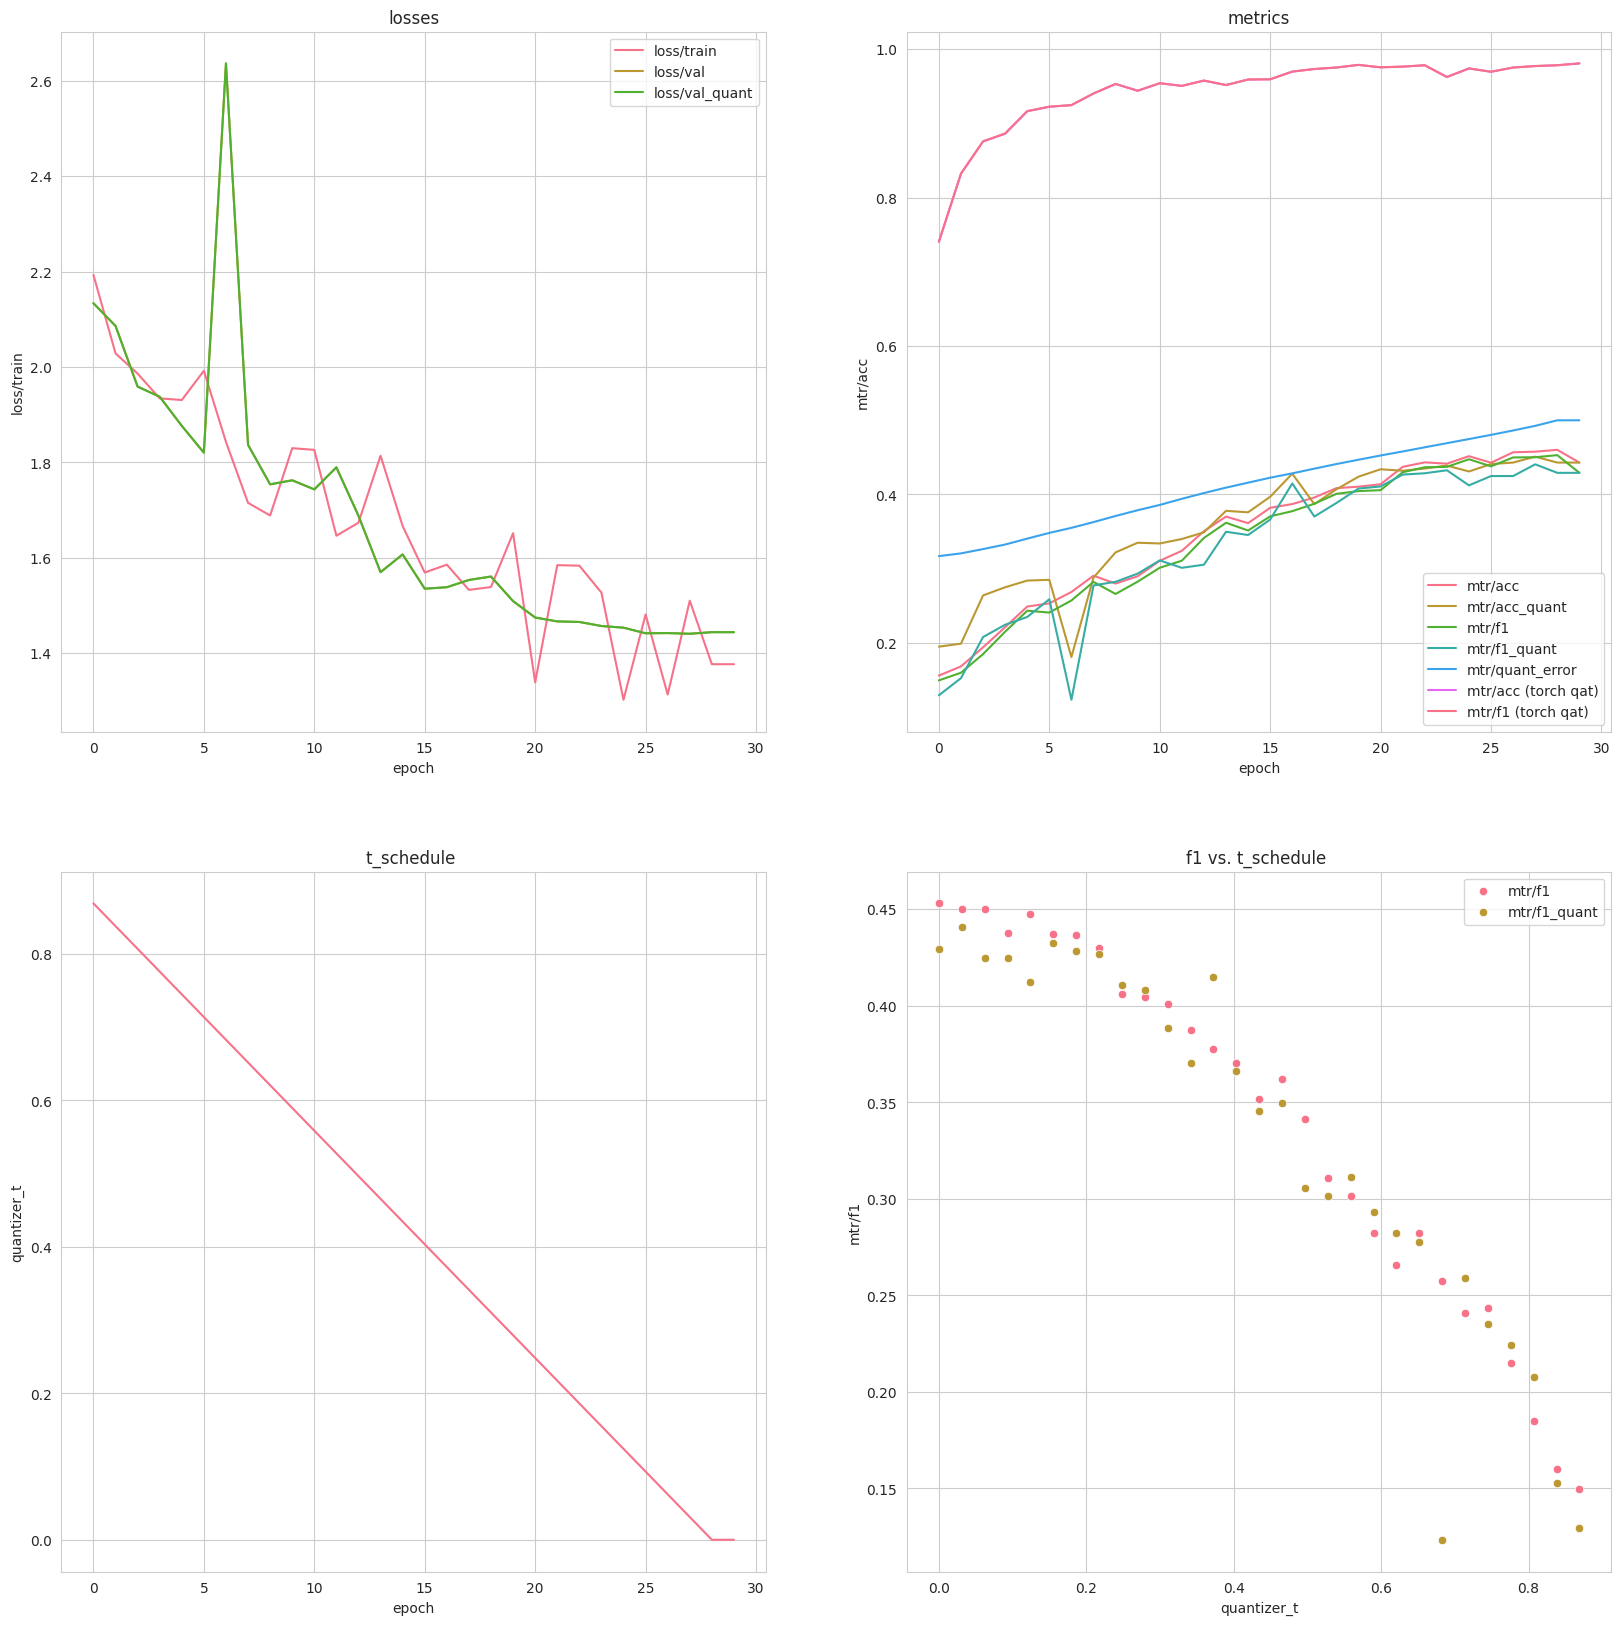

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# Set Seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")


def plot_dynamics(name, scale='step', metric='acc', axes=None, suffix=''):
    dynamics, final_results = read_results(name, scale)
    
    if axes is None: 
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))

    # losses
    for c in [c for c in dynamics.columns if c.startswith('loss/')]:
        sns.lineplot(dynamics, x=scale, y=c, ax=axes[0][0], label=c + suffix)
    axes[0][0].legend()
    axes[0][0].set_title('losses') 

    # mtr

    for c in [c for c in dynamics.columns if c.startswith('mtr/')]:
        sns.lineplot(dynamics, x=scale, y=c, ax=axes[0][1], label=c + suffix)
    axes[0][1].legend()
    axes[0][1].set_title('metrics') 

    if not 'quantizer_t' in dynamics:
        return axes

    # t schedule 
    
    ax = axes[1][0] 
    sns.lineplot(dynamics, x=scale, y='quantizer_t', ax=ax)
    ax.set_title(f't_schedule ')

    # metric vs. t_schedule 

    ax = axes[1][1]
    for c in [c for c in dynamics.columns if metric in c]:
        sns.scatterplot(dynamics, x='quantizer_t', y=c, ax=ax, label=c)
    # sns.scatterplot(dynamics, x='quantizer_t', y=f'train_{metric}', ax=ax)
    ax.set_title(f'{metric} vs. t_schedule ')
    return axes 


# plot_dynamics('InceptionNet_STL10_b4', 'epoch')
def plot_comparison(exp, baseline, scale, metric):
    axes = plot_dynamics(exp, scale, metric)
    axes = plot_dynamics(baseline, scale, metric, axes, ' (torch qat)')

plot_comparison('InceptionNet_STL10_b8', 'InceptionNet_STL10_b8_torch', 'epoch', 'f1')

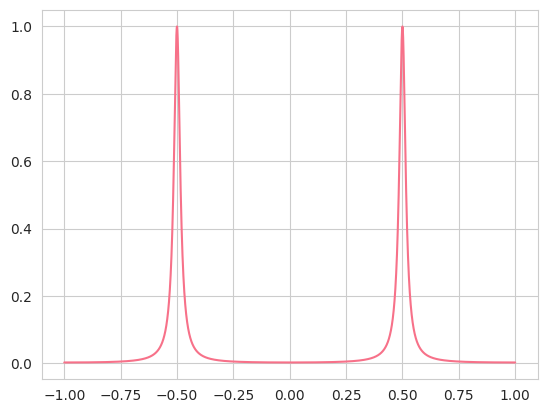

In [26]:
from softstairs_qat.core.soft_stairs import softstairs_naive 
import math 


def softstairs_naive(x, t):
     return x + (1 / math.pi) * torch.atan2(
            -(1 - t) * torch.sin(2 * math.pi * x),
            t + 2 * (1 - t) * torch.square(torch.cos(math.pi * x))
        ) - 0.5

def derivative( x: torch.Tensor, t, normalized) -> torch.Tensor:
        """Compute the SoftStairs derivative used during backpropagation.

        Args:
            x: Input tensor in normalized quantization coordinates.
        Returns:
            Element-wise derivative with the same shape as ``x``.
        """
        den = (t * t + 4 * (1 - t) * torch.square(torch.cos(math.pi * x)))
        if normalized:
            nom = t * t
        else:
            nom = (2 - t) * t 
        deriv = nom / den
        # deriv = (1.0 - self.r) * (1.0 - self.r) / (
        #     1.0 + 2.0 * self.r * torch.cos_(2.0 * math.pi * x) + self.r * self.r
        # )
        return deriv

t = .1
x = torch.linspace(-1, 1, 10000)
y = derivative(x, t, True)

plt.plot(x, y)

In [27]:
def read_grad_param(path):
    grads = []
    params = []
    epochs = []
    for file in os.listdir(path):
        print(file)
        tp, epoch = file[:-4].split('_')
        epochs.append(int(epoch))
        filepath = path + '/' + file
        print(filepath)
        tensor = torch.load(filepath)
        
        if tp == 'grad':
            grads.append(tensor)
        else:
            params.append(tensor)
    return torch.stack(grads), torch.stack(params)


G, P = read_grad_param('/home/leostre/Рабочий стол/SoftStairs-QAT/experiments/CV/logs/InceptionNet_STL10_b8/version_6/fc.weight')

FileNotFoundError: [Errno 2] No such file or directory: '/home/leostre/Рабочий стол/SoftStairs-QAT/experiments/CV/logs/InceptionNet_STL10_b8/version_6/fc.weight'

In [ ]:
torch.load('/home/leostre/Рабочий стол/SoftStairs-QAT/experiments/CV/logs/InceptionNet_STL10_b8/version_6/fc.weight/grad_27.pth')

tensor([[ 1.9350e-08,  5.7098e-08,  9.0796e-08,  ...,  1.3715e-06,
          6.5268e-07,  3.4037e-08],
        [ 2.1376e-08, -3.2508e-08,  8.4724e-09,  ...,  3.7218e-08,
          4.5971e-08,  6.3747e-08],
        [-6.3794e-09, -1.0088e-08, -6.1678e-08,  ..., -3.6665e-07,
          3.2092e-08,  2.5253e-09],
        ...,
        [ 4.6014e-06,  1.2123e-06,  1.5101e-07,  ...,  1.7169e-08,
          4.8270e-08,  4.6782e-06],
        [ 6.5878e-08,  4.1673e-09, -3.0023e-08,  ..., -2.6163e-08,
         -6.4076e-08, -9.8673e-08],
        [-4.1346e-07,  3.1944e-08,  2.7137e-07,  ...,  1.4232e-07,
          5.2619e-08,  1.9666e-07]], device='cuda:0')